## Visual results

In [32]:
dir_path = "img"

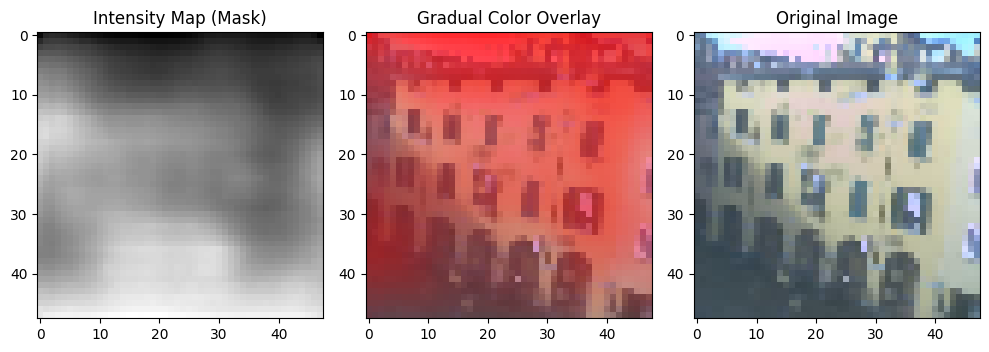

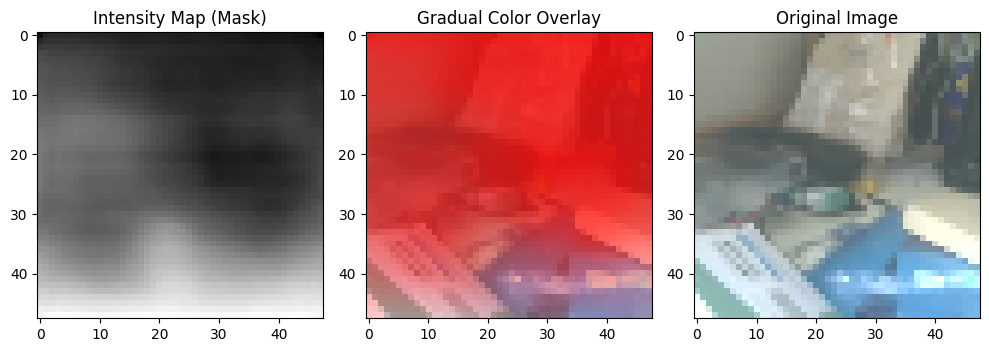

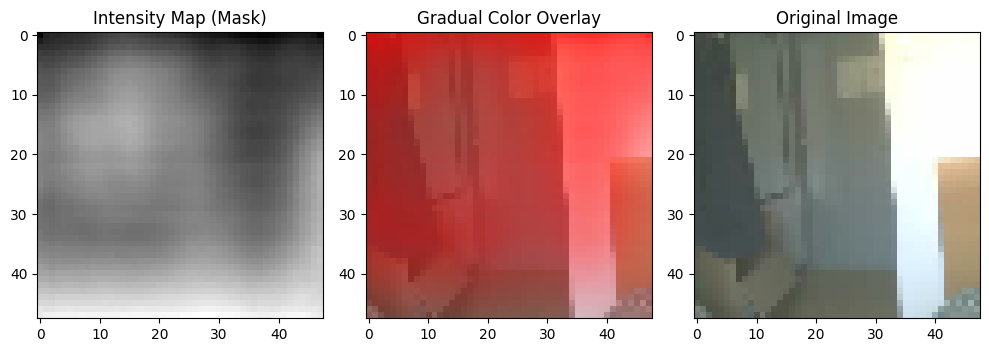

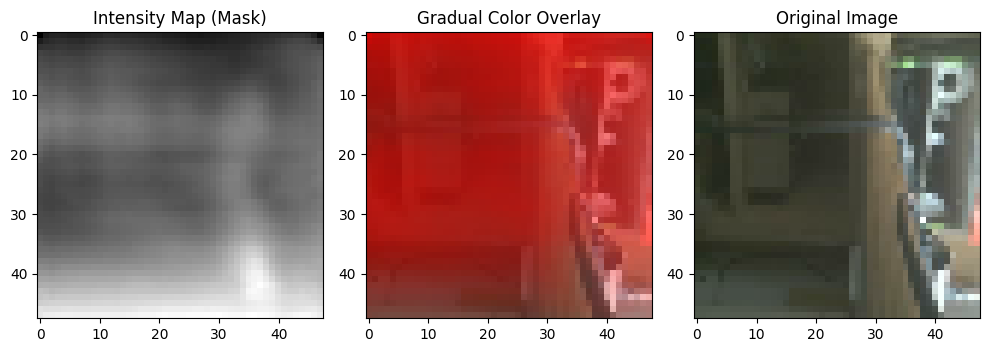

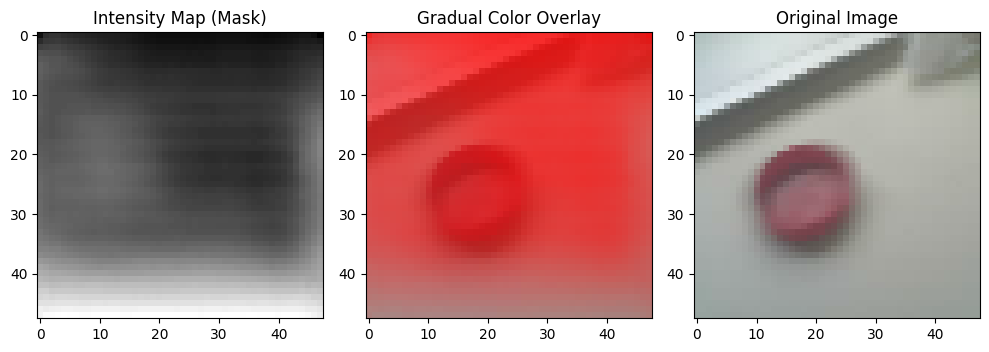

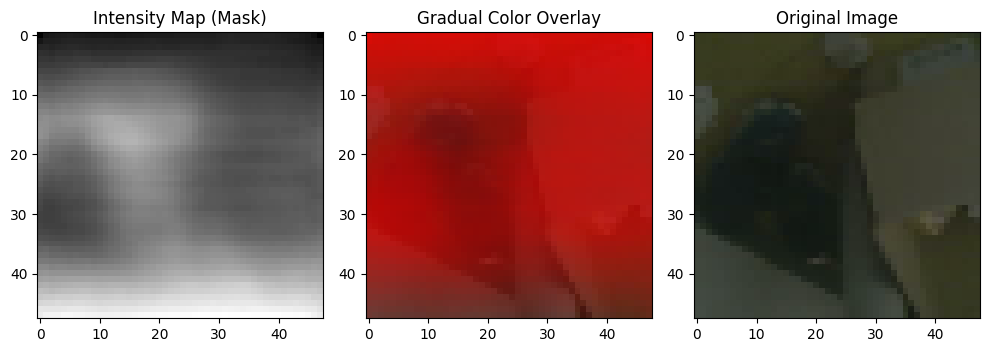

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def apply_weighted_overlay(image, mask, color=[0, 0, 255]):
    """
    Applies a color overlay based on mask intensity (0-255).
    """
    img_float = image.astype(float)
    
    alpha_map = mask.astype(float) / 255.0
    
    result = np.zeros_like(img_float)
    
    # Apply the linear interpolation formula (vectorized)
    # For each channel (R, G, B): (1 - alpha) * Image + alpha * Target_Color
    for i in range(3):
        result[:, :, i] = (1.0 - alpha_map) * img_float[:, :, i] + alpha_map * color[i]
        
    return result.astype(np.uint8)

amount = len(os.listdir(dir_path)) // 4

for num in range(0, amount * 4, 4):
    path_img = os.path.join(dir_path, f"{num}_RGB_SMALL.bmp")
    path_mask = os.path.join(dir_path, f"{num}depth_map.bmp") 

    img_bgr = cv2.imread(path_img)
    mask_gray = cv2.imread(path_mask, 0)

    if img_bgr is not None and mask_gray is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        img_rgb = cv2.resize(img_rgb, (48, 48))
        mask_gray = cv2.resize(mask_gray, (48, 48))

        result = apply_weighted_overlay(img_rgb, 255 - mask_gray, color=[255, 0, 0])

        fig, ax = plt.subplots(1, 3, figsize=(10, 5))
        ax[0].imshow(mask_gray, cmap='gray')
        ax[0].set_title("Intensity Map (Mask)")
        
        ax[1].imshow(result)
        ax[1].set_title("Gradual Color Overlay")
        
        ax[2].imshow(img_rgb)
        ax[2].set_title("Original Image")
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Error: Could not load files. Check paths: {path_img} or {path_mask}")

## Plots above cycle counters

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# notice: this is literally copy-pasted by the ESP logs
raw_text = """
[Inference] OP: CONV_2D                   ... Cycles: 9793585
[Inference] OP: LEAKY_RELU                ... Cycles: 2368677
[Inference] OP: CONV_2D                   ... Cycles: 21238332
[Inference] OP: LEAKY_RELU                ... Cycles: 2375751
[Inference] OP: CONV_2D                   ... Cycles: 9418002
[Inference] OP: LEAKY_RELU                ... Cycles: 1180923
[Inference] OP: CONV_2D                   ... Cycles: 17677536
[Inference] OP: LEAKY_RELU                ... Cycles: 1206081
[Inference] OP: CONV_2D                   ... Cycles: 8369997
[Inference] OP: LEAKY_RELU                ... Cycles: 590462
[Inference] OP: CONV_2D                   ... Cycles: 16301091
[Inference] OP: LEAKY_RELU                ... Cycles: 585421
[Inference] OP: CONV_2D                   ... Cycles: 16307844
[Inference] OP: LEAKY_RELU                ... Cycles: 584978
[Inference] OP: CONV_2D                   ... Cycles: 16291527
[Inference] OP: LEAKY_RELU                ... Cycles: 580386
[Inference] OP: CONV_2D                   ... Cycles: 16309775
[Inference] OP: SHAPE                     ... Cycles: 2095
[Inference] OP: STRIDED_SLICE             ... Cycles: 14550
[Inference] OP: PACK                      ... Cycles: 5846
[Inference] OP: TRANSPOSE_CONV            ... Cycles: 96971912
[Inference] OP: CONCATENATION             ... Cycles: 333327
[Inference] OP: CONV_2D                   ... Cycles: 97124784
[Inference] OP: LEAKY_RELU                ... Cycles: 2417253
[Inference] OP: CONV_2D                   ... Cycles: 65269272
[Inference] OP: LEAKY_RELU                ... Cycles: 2428491
[Inference] OP: CONV_2D                   ... Cycles: 65295186
[Inference] OP: SHAPE                     ... Cycles: 2731
[Inference] OP: STRIDED_SLICE             ... Cycles: 7607
[Inference] OP: PACK                      ... Cycles: 3205
[Inference] OP: TRANSPOSE_CONV            ... Cycles: 388028786
[Inference] OP: CONCATENATION             ... Cycles: 1119693
[Inference] OP: CONV_2D                   ... Cycles: 325053822
[Inference] OP: LEAKY_RELU                ... Cycles: 9647814
[Inference] OP: CONV_2D                   ... Cycles: 261281916
[Inference] OP: LEAKY_RELU                ... Cycles: 9638034
[Inference] OP: CONV_2D                   ... Cycles: 26050902
"""

color_map = {
    'CONV_2D': '#e74c3c',
    'LEAKY_RELU': '#3498db',      
    'TRANSPOSE_CONV': '#e67e22', 
    'CONCATENATION': '#9b59b6',  
    'STRIDED_SLICE': '#2ecc71',
    'SHAPE': '#95a5a6',        
    'PACK': '#f1c40f',         
    'OTHER': '#bdc3c7'
}

# These are the most 3 expensive operations: let's see how much impact they have
main_ops_for_pie = ['CONV_2D', 'LEAKY_RELU', 'TRANSPOSE_CONV']

names = []
cycles = []
bar_colors = []
pie_data = {op: 0 for op in main_ops_for_pie}
pie_data['OTHER'] = 0

for line in raw_text.split("\n"):
    if "OP:" in line:
        parts = line.split("...")
        op_type = parts[0].split("OP:")[1].strip()
        cycle_val = int(parts[1].split(":")[1].strip())
        
        # Data for Bar Chart
        names.append(f"{len(names)+1}_{op_type}")
        cycles.append(cycle_val)
        bar_colors.append(color_map.get(op_type, color_map['OTHER']))
        
        # Data for Pie Chart: Aggregate logic
        if op_type in main_ops_for_pie:
            pie_data[op_type] += cycle_val
        else:
            pie_data['OTHER'] += cycle_val



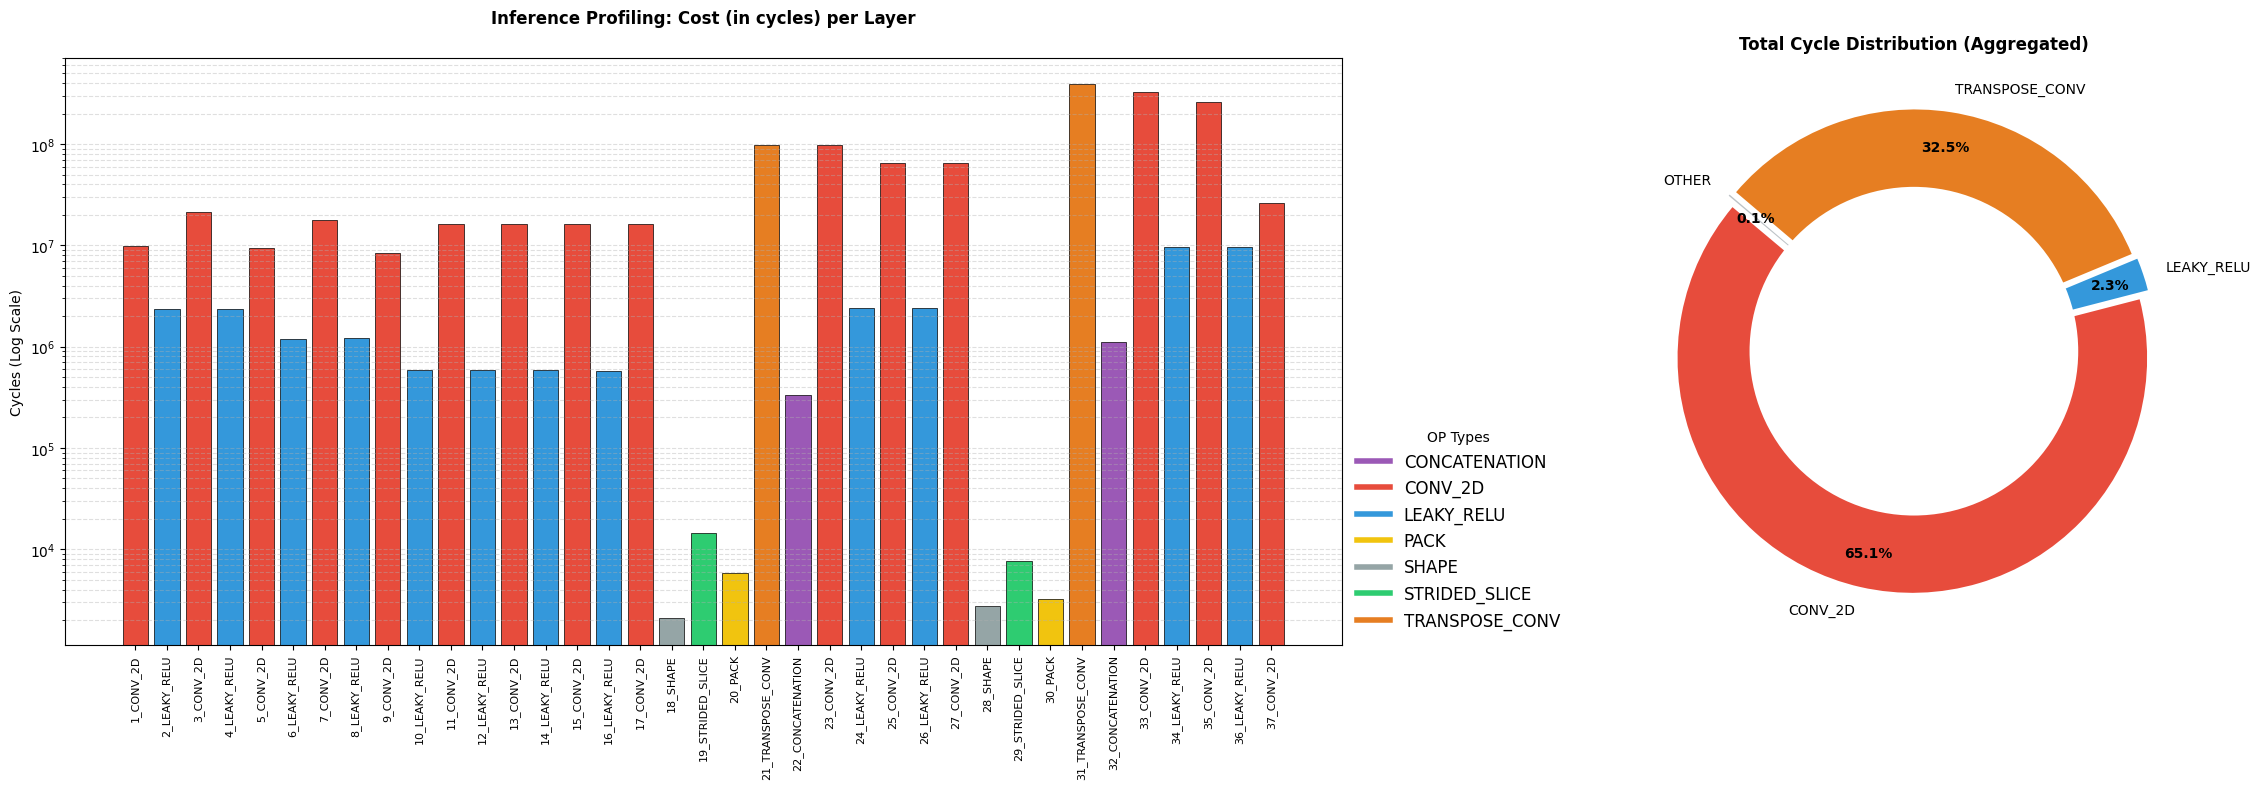

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 8), gridspec_kw={'width_ratios': [2, 1]})

# Bar Chart (Log Scale)
ax1.bar(names, cycles, color=bar_colors, edgecolor='black', linewidth=0.5)
ax1.set_yscale('log')
ax1.set_xticks(range(len(names))) # Ensure ticks match names length
ax1.set_xticklabels(names, rotation=90, fontsize=8)
ax1.set_ylabel("Cycles (Log Scale)")
ax1.set_title("Inference Profiling: Cost (in cycles) per Layer", fontweight='bold', pad=25) # Added padding for title
ax1.grid(axis='y', which='both', linestyle='--', alpha=0.4)

unique_ops = sorted(list(set([n.split('_', 1)[1] for n in names])))
legend_elements = [Line2D([0], [0], color=color_map.get(op, color_map['OTHER']), lw=4, label=op) for op in unique_ops]

ax1.legend(handles=legend_elements, title="OP Types", 
           loc='lower left', 
           bbox_to_anchor=(1, 0), 
           ncol=1,
           fontsize='large', 
           frameon=False)

# Donut Pie Chart
labels = [k for k, v in pie_data.items() if v > 0]
sizes = [pie_data[k] for k in labels]
colors = [color_map[label] for label in labels]

explode = [0.03] * len(labels)


wedges, texts, autotexts = ax2.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                  colors=colors, startangle=140, pctdistance=0.85,
                                  explode=explode) 
ax2.set_title("Total Cycle Distribution (Aggregated)", fontweight='bold')

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax2.add_artist(centre_circle)

#Plot fn
plt.setp(autotexts, size=10, weight="bold")
plt.tight_layout(w_pad=2.0)
plt.savefig("../example_images/inference_profiling.png", dpi=300, bbox_inches='tight')
plt.show()

